# A Guide to Agentic Design patterns in LangGraph

### Introduction
Building sophisticated AI agents involves more than just connecting to an LLM. It requires structuring the agent's behavior through specific **design patterns**. These patterns are reusable blueprints that define how an agent thinks, acts, remembers, and makes decisions.

This tutorial will walk you through the four key agentic design patterns, in the order they were introduced, from basic tool use to advanced self-correction.

1.  **Tool-Augmented LLMs (The Foundation)**
2.  **The ReAct Pattern**
3.  **The Conversational Memory Pattern**
4.  **The Router Pattern**
5.  **The Reflection (Self-Correction) Pattern**

---


![choose-design-pattern-agentic-ai-system-sequential[1].svg]()

---

## 1. Tool-Augmented LLMs

The most fundamental step in building agents is augmenting an LLM with the ability to use **tools**. This is the foundational capability that allows an agent to interact with the outside world, breaking free from the limitations of its static training data.

### **What is it?**
This pattern involves "binding" one or more tools (like a web search or a calculator) to an LLM. The model is then able to decide, based on the user's prompt, whether to answer directly from its own knowledge or to call a tool to get the information it needs.

### **How does it work?**
In a simple tool-augmented setup, the LLM makes a single decision:
* **Path A:** If the query is something like "Explain AI," the LLM answers directly.
* **Path B:** If the query is "What's the latest news on NVIDIA?", the LLM recognizes it needs external information and makes a **tool call** to a search function.

This is a one-step decision process. In LangGraph, this is often the starting point, implemented by binding tools to the LLM and using a conditional edge (`tools_condition`) to route to a `ToolNode` if a tool is called.

---


![choose-design-pattern-agentic-ai-system-single-agent[1].svg]()

---

## 2. The ReAct Pattern

The **ReAct** pattern is a more advanced and structured way to use tools. It's not just about deciding *whether* to use a tool, but about creating a multi-step reasoning process to solve more complex problems.

### **What is it?**
**ReAct** stands for **"Reason + Act"**. It's a specific agentic pattern that synergizes an LLM's ability to reason with its ability to take actions in an iterative loop. This allows the agent to plan, execute, observe the outcome, and then re-plan.

### **How does it work?**
The ReAct pattern follows a deliberate, cyclical process: **Thought → Action → Observation**.

1.  **Thought:** The LLM first generates an explicit reasoning trace. It thinks about the overall problem, breaks it down, and decides which specific tool to use and what input to provide.
2.  **Action:** The LLM executes the tool call it decided upon in the "Thought" step.
3.  **Observation:** The LLM receives the output from the tool and observes the result. This new information is then used to generate the next "Thought," allowing the agent to string together multiple tool calls to solve a problem.

The key difference from simple tool-use is the explicit, intermediate **"Thought"** step, which creates a chain of reasoning that you can follow.

### **Example Application:**
The **Financial Analyst Agent** is a perfect example of the ReAct pattern. For a query like "Compare the P/E ratio of Apple and Microsoft," the agent would:
1.  **Think:** "I need to find the P/E for Apple first. I'll use the `get_stock_ticker` tool."
2.  **Act:** Call `get_stock_ticker('Apple')`.
3.  **Observe:** Get back the ticker "AAPL."
4.  **Think:** "Now I have the ticker. I'll use `get_stock_fundamental_indicator_metrics` for AAPL."
5.  ...and so on, until it has gathered all the necessary information.

---


![https___substack-post-media.s3.amazonaws.com_public_images_d02b2eaa-16c3-4f92-8f97-06329fbcccd4_716x550[1].gif](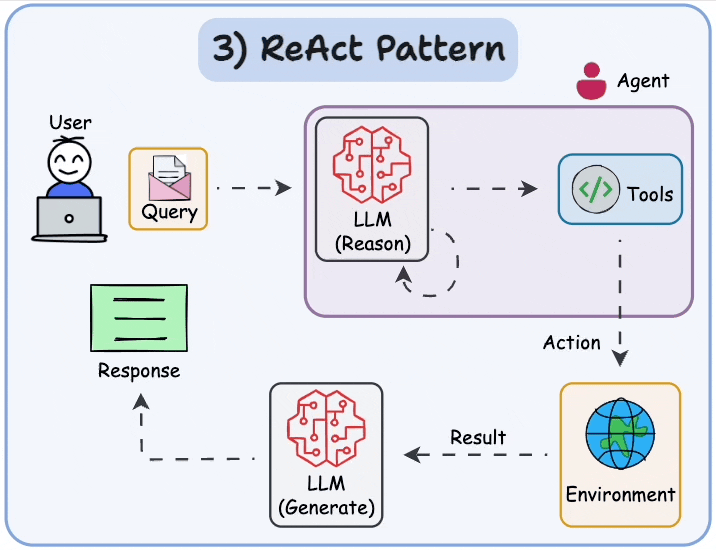)

---

## 3. The Conversational Memory Pattern

While a ReAct agent is powerful, it is stateless by default. The Conversational Memory pattern solves this by giving the agent a memory to recall past interactions, enabling stateful, multi-user conversations.

### **What is it?**
This pattern involves storing and retrieving the history of messages in a conversation. This allows the agent to understand context, handle follow-up questions, and provide a personalized experience for each user.

### **How does it work?**
This is implemented in LangGraph using a **Checkpointer** (like `MemorySaver` or `SqliteSaver`). Each conversation is assigned a unique **`thread_id`**, which the checkpointer uses to save and load the sequence of messages for that specific conversation.

As conversations get longer, this pattern also includes strategies for memory management:
* **Trimming Messages:** Removing older messages to stay within the LLM's context window.
* **Summarizing Conversations:** Using an LLM to create a concise summary of earlier parts of the conversation.

### **Example Application:**
The **Multi-User Conversational Financial Analyst Agent** builds upon the ReAct agent by adding a memory component, allowing it to handle distinct, ongoing conversations with multiple users simultaneously and remember the context of each one.

---


---

## 4. The Router Pattern

As agentic systems become more complex, they need to handle a wider variety of tasks. The Router Pattern introduces a specialized agent that acts as a central decision-maker, directing tasks to the most appropriate workflow or node for processing.

### **What is it?**
A router is a component that analyzes an incoming query and uses **conditional routing** to send it down the correct path in the graph. This allows you to build systems with specialized "departments" for handling different types of requests.

### **How does it work?**
The router uses an LLM to evaluate the user's input and classify it. The output of this classification is then used by a conditional edge to determine the next node to execute, enabling dynamic, context-aware workflow management.

### **Example Application:**
The **Customer Support Router Agentic RAG System** is a key example. It first analyzes a user's query to determine its `category` and `sentiment`. Based on this analysis, the router directs the query to the correct response-generation node (e.g., "Billing", "Technical") or escalates it to a human.

---


![routing-or-handoff[1].png](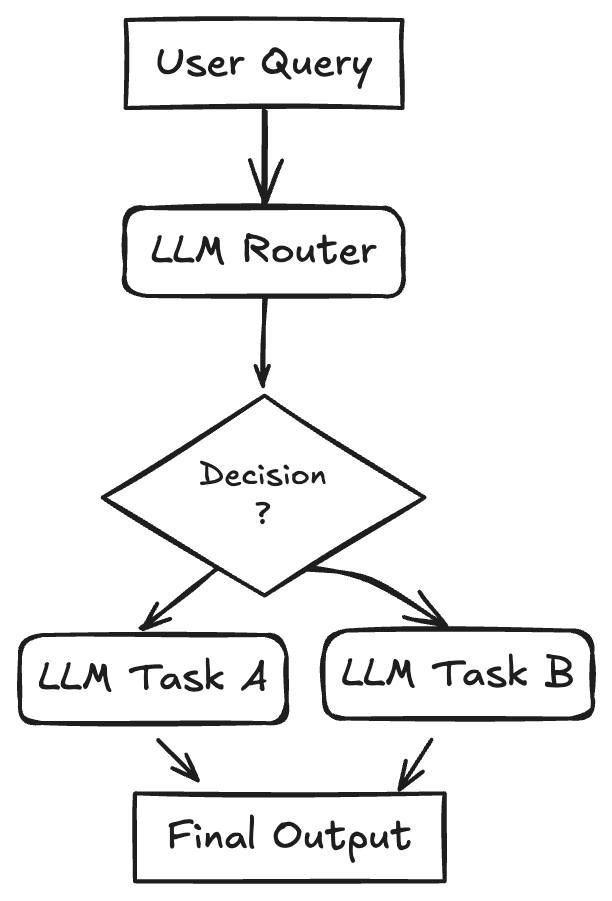)

---

## 5. The Reflection (Self-Correction) Pattern

This is a more advanced pattern that gives an agent the ability to iteratively review and improve its own work, creating a powerful feedback loop for self-correction.

### **What is it?**
The Reflection Pattern enables an LLM to generate an initial output, critique it to identify flaws or areas for improvement, and then modify it based on that critique.

### **How does it work?**
The pattern operates in a cycle: **Generate → Reflect → Modify → Repeat**.

1.  **Generate:** The agent creates an initial solution.
2.  **Reflect:** The agent (or another part of the system) reviews the output. In the context of code generation, this "reflection" is done by executing the code and checking for errors.
3.  **Modify:** The feedback from the reflection step (e.g., an error message) is fed back to the agent, which then revises its solution.
4.  **Repeat:** This loop continues until the solution is correct or a predefined stopping condition is met.

### **Example Application:**
The **Reflective Self-Correcting Code Generation Agent** is the key example. This agent receives a user request for code, generates a solution, and then tries to execute it. If the code fails, the error message is passed back to the agent, which is prompted to reflect on the error and generate a corrected version.

![reflection[1].png](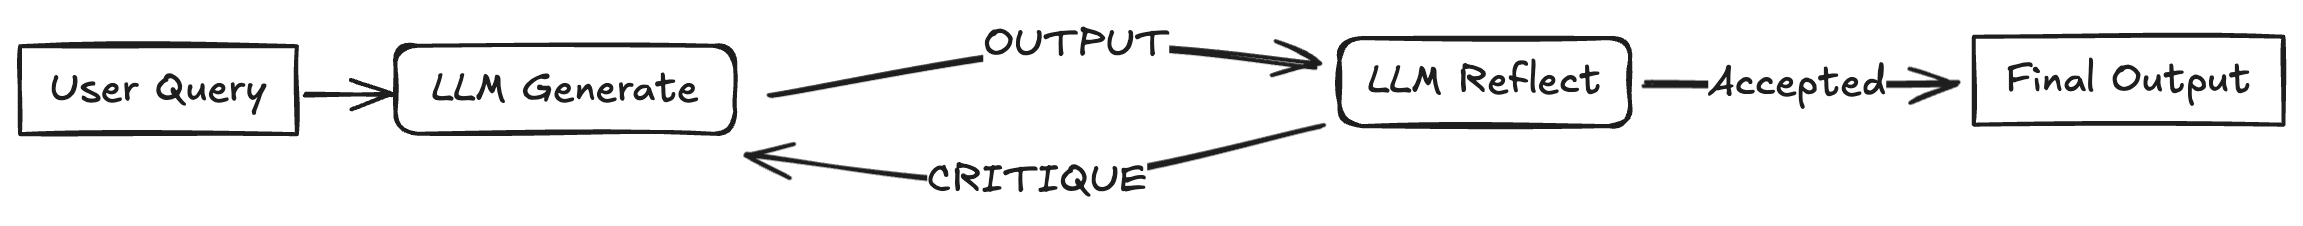)

---
---


## 6.⚡ Parallel Execution (Fan-Out/Fan-In) Pattern

This pattern is designed to improve the speed and efficiency of an agent by allowing it to perform multiple independent tasks at the same time.

### **What is it?**
Instead of executing a linear sequence of steps, this pattern allows the agent's workflow to branch out to run several nodes in parallel and then converge the results back together for a final synthesis step.

### **How does it work?**
It uses two key mechanisms in the graph's structure:
* **Fan-Out:** A single node branches out to multiple nodes, allowing for the simultaneous execution of tasks. For example, a starting node can trigger both a web search and a Wikipedia search at the same time.
* **Fan-In:** Multiple parallel nodes converge back into a single node. The graph intelligently waits for all the parallel tasks to complete before executing this single, aggregate node.


![choose-design-pattern-agentic-ai-system-parallel[1].svg]()

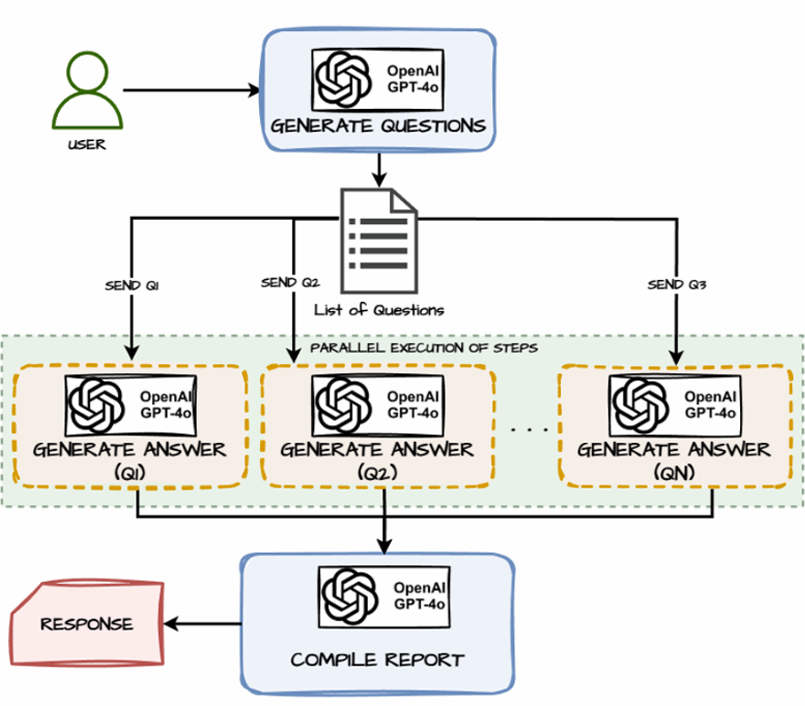

### **Why is it useful?**
The main benefit is **reducing latency**. Many agentic tasks involve gathering information from multiple independent sources. Running these data-gathering steps in parallel significantly reduces the total time a user has to wait for a response, making the agent feel much faster and more responsive.

### **Example Application:**
The Deep Research & Structured Report Generation Project demonstrates a practical use case where an agent needs to answer a question using information from two different sources.
1.  **Fan-Out:** The user's question triggers two parallel tasks: one node searches the web using Tavily (`search_web`), and another node searches a specific knowledge base (`search_wikipedia`).
2.  **Fan-In:** Both search tasks feed their results into a single `generate_answer` node. This node waits for both searches to complete, then synthesizes the combined information into one final, comprehensive answer for the user.

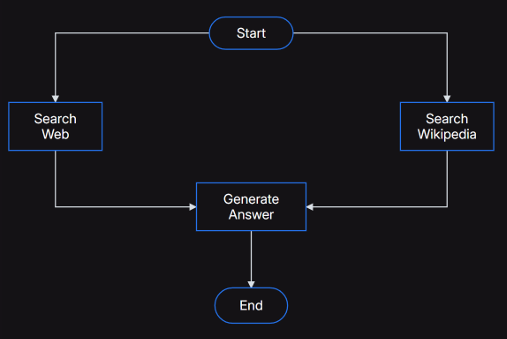

Here are crisp, real-world business use cases for the six agentic design patterns we've discussed.

### **1. Tool-Augmented LLMs**
This foundational pattern involves giving an LLM access to one or more tools to fetch external information.

* **Production Example:** **ChatGPT with Browse with Bing.** When a user asks for information on a very recent event, ChatGPT uses its browsing tool to search the live web, as its internal knowledge is not up-to-date.
* **Business Use Case:** An internal knowledge bot for a sales team. When a salesperson asks, "What's the current stock level for product X?", the agent uses a tool to query the company's inventory database API and provide a real-time answer.

---
### **2. The ReAct Pattern**
This is a more advanced tool-use pattern where the agent follows a **Thought → Action → Observation** loop to solve multi-step problems.

* **Production Example:** **Zapier's AI-powered workflows.** A user can state a complex goal like, "When a new lead is added to my Salesforce, find their company's domain, research their latest press release, and draft a personalized outreach email." The agent thinks through the steps, calls the Salesforce tool, then the web search tool, and finally the Gmail tool in a deliberate sequence.
* **Business Use Case:** An automated financial analysis agent, like the one from the project. When asked to "compare two stocks," it follows a ReAct loop: think about the first stock, act by calling a tool to get its data, observe the result, then think about the second stock, and so on.

---
### **3. The Conversational Memory Pattern**
This pattern gives an agent a memory to recall the history of its conversation with a specific user.

* **Production Example:** **Modern e-commerce chatbots.** A user might ask, "Do you have any blue shirts?" After the bot shows some options, the user can ask, "What about in a size medium?" The bot uses memory to know the user is still asking about blue shirts.
* **Business Use Case:** A multi-turn technical support agent. It guides a user through a debugging process, remembering the user's previous answers ("Yes, I already tried restarting the device") to avoid asking redundant questions.

---
### **4. The Router Pattern**
This pattern uses a central agent to analyze an incoming query and route it to the most appropriate specialized sub-agent or tool.

* **Production Example:** **The "GPTs" feature in ChatGPT.** When you start a conversation, a top-level router analyzes your prompt. If you upload a PDF, it routes you to a document analysis GPT; if you ask for a diagram, it might route you to a diagramming GPT.
* **Business Use Case:** A corporate helpdesk agent for a large enterprise. It acts as a single point of contact, routing an employee's query to the correct department: "My laptop won't connect to Wi-Fi" is routed to the **IT support** sub-agent, while "How do I request paid time off?" is routed to the **HR** sub-agent.

---
### **5. The Reflection (Self-Correction) Pattern**
This pattern allows an agent to create a solution, test it, analyze the results (reflect), and then iteratively improve it.

* **Production Example:** **GitHub Copilot Workspace.** A developer can give Copilot a high-level task (e.g., "add a new API endpoint for user profiles"). Copilot generates a plan and the initial code, then attempts to run the build and tests. If the tests fail, it reads the error log (reflection) and attempts to fix its own code (self-correction).
* **Business Use Case:** An automated data quality assurance agent. The agent is tasked with writing a script to clean a dataset. It generates the script, runs it on a sample of the data, and then checks the output for anomalies (e.g., null values, incorrect data types). If it finds issues, it reflects on the problem and rewrites the script to handle those edge cases.

---
### **6. The Parallel Execution (Fan-Out/Fan-In) Pattern**
This structural pattern enables an agent to execute multiple independent tasks simultaneously to reduce waiting time.

* **Production Example:** **Perplexity AI.** When you ask a complex question that requires information from multiple domains, it often runs several distinct web search queries in parallel. It then synthesizes the information from all these concurrent searches to give you a single, comprehensive answer much faster than if it had searched sequentially.
* **Business Use Case:** A market intelligence agent tasked with creating a "competitor snapshot." When asked about a competitor, it can run these tasks in parallel:
    * **Node A:** Scrape the competitor's website for product descriptions.
    * **Node B:** Search for their latest financial news.
    * **Node C:** Pull their stock price history from an API.
    The agent then fans in the results from all three nodes to generate a consolidated report for the marketing team.

---
---
## 👨‍💻 7. The Human-in-the-Loop Pattern

This pattern is crucial for creating agents that are not only autonomous but also safe, reliable, and collaborative.

* **What is it?**
    A workflow where the agent is designed to pause at a predefined step and cede control to a human. The agent's execution is interrupted until the human provides feedback, makes a decision, or takes an action.

* **Why is it useful?**
    * **Oversight and Safety:** It's essential for high-stakes tasks where an autonomous error could be costly (e.g., approving a large financial transaction or deleting data).
    * **Handling Ambiguity:** When an agent is stuck or encounters a situation it wasn't designed for, it can escalate to a human for help instead of failing or hallucinating.
    * **Collaboration:** It allows for a partnership where the agent handles the tedious, repetitive parts of a task, and the human provides the final judgment, creativity, or strategic direction.

* **How does it work?**
    LangGraph's persistence and memory features are what enable this pattern. The agent can save its complete state at an "interrupt" point. A human can then review that state, provide new input (which updates the state), and the agent can resume its work from that exact point without losing context.

* **Example Applications:**
    * **Customer Support Escalation:** The **Customer Support Router Agent** has an explicit path to "EscalateToHuman". If the agent detects a customer's sentiment is negative, its routing logic intentionally stops the automated response process and flags the conversation for a human agent to take over.
    * **User Feedback on Code Generation:** The **Reflective Self-Correcting Code Generation Agent** includes a "User Feedback Loop". Even if the agent thinks the code is correct (because it runs without errors), the human user has the final say. If the user is unsatisfied, they can reject the solution, which sends the agent back into its reflection and correction cycle.

Some Additional Real-world business use cases for the Human-in-the-Loop pattern.

* **Medical Imaging Analysis:** In healthcare, an AI agent can analyze thousands of medical scans (like MRIs or X-rays) to detect and flag potential abnormalities or signs of disease. The system then pauses and presents these flagged scans, along with its preliminary findings, to a human radiologist for final review and diagnosis. The human makes the critical decision, but the agent dramatically speeds up the process.

* **Financial Fraud and Compliance Approval:** Banks and financial institutions use agents to monitor transactions in real-time. The agent can autonomously approve standard transactions but will pause and trigger a human-in-the-loop workflow for high-value transfers or transactions that match a fraud-risk profile. A human compliance officer must then manually review and approve or deny the transaction before it proceeds.

* **Content Moderation:** Social media platforms use AI agents to scan millions of posts, images, and videos for policy violations. Content that is clearly in violation is handled automatically. However, content that is ambiguous or falls into a grey area is flagged and routed to a queue for human moderators to review and make a final judgment call.